# Persistance Memory

In [12]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

from typing import TypedDict

In [13]:
from dotenv import load_dotenv
load_dotenv()
import os

In [14]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3, max_tokens=2000
    )

llm = get_groq_llm()


In [15]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [16]:
def generate_joke(state: JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content
    return {'joke': response}

In [17]:
def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content
    return {'explanation': response}

In [18]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = MemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

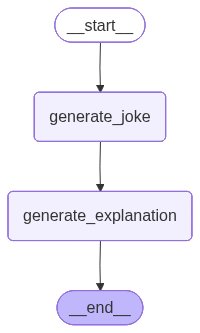

In [19]:
workflow

In [20]:
config1 = {
    "configurable": {
        "thread_id": "1"
        }
    }

In [21]:
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '**Why the joke works – a quick “crust‑of‑a‑living” pun**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|----------------------------------|\n| **The set‑up** | “Why did the pizza apply for a job?” | It immediately anthropomorphizes the pizza, making it a character that can think, act, and even seek employment. That absurdity alone sets the stage for a playful punchline. |\n| **The punchline** | “Because it wanted to get a *crust* of a living!” | The humor comes from a *word‑play* (a pun). |\n| **The pun itself** | “Crust” sounds like “cost” (especially in some accents) and is also a literal part of a pizza. | 1. **Literal meaning** – a pizza’s crust is the outer edge of the dough. 2. **Figurative meaning** – “cost of living” is a common phrase that refers to how much money one needs to earn to cover expenses. By

In [22]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick “crust‑of‑a‑living” pun**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|----------------------------------|\n| **The set‑up** | “Why did the pizza apply for a job?” | It immediately anthropomorphizes the pizza, making it a character that can think, act, and even seek employment. That absurdity alone sets the stage for a playful punchline. |\n| **The punchline** | “Because it wanted to get a *crust* of a living!” | The humor comes from a *word‑play* (a pun). |\n| **The pun itself** | “Crust” sounds like “cost” (especially in some accents) and is also a literal part of a pizza. | 1. **Literal meaning** – a pizza’s crust is the outer edge of the dough. 2. **Figurative meaning** – “cost of living” is a common phrase that refers to how much money one needs to earn to

## The Audit Trail (Fetching State History)

In [26]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick “crust‑of‑a‑living” pun**\n\n| Element | What it is | How it contributes to the humor |\n|---------|------------|----------------------------------|\n| **The set‑up** | “Why did the pizza apply for a job?” | It immediately anthropomorphizes the pizza, making it a character that can think, act, and even seek employment. That absurdity alone sets the stage for a playful punchline. |\n| **The punchline** | “Because it wanted to get a *crust* of a living!” | The humor comes from a *word‑play* (a pun). |\n| **The pun itself** | “Crust” sounds like “cost” (especially in some accents) and is also a literal part of a pizza. | 1. **Literal meaning** – a pizza’s crust is the outer edge of the dough. 2. **Figurative meaning** – “cost of living” is a common phrase that refers to how much money one needs to earn t

## Time Travel (Replaying Past States) using checkpoint_id

In [ ]:
workflow.invoke(None, {
    'configurable': {
        'thread_id': '1',
        'checkpoint_id': '1f156bac-7e34-6c90-8001-c76097cb4415'
        }
    }
)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '**Why did the pizza apply for a job?  \nBecause it wanted to get a *crust* of a living!**\n\n---\n\n### The punchline is a pun\n\n| Word in the joke | Literal meaning | Wordplay |\n|------------------|-----------------|----------|\n| **Crust** | The outer, baked edge of a pizza. | Sounds like “cost” (the amount you pay) and also plays on the phrase “to get a living.” |\n| **Living** | A way to earn money, i.e., a salary or wage. | The joke twists the idiom “to get a living” into “to get a *crust* of a living.” |\n\nSo the joke hinges on the double meaning of **crust**:\n\n1. **Crust** is a real part of a pizza.  \n2. **Crust** sounds like **cost** (the price you pay for something) and is used humorously to replace the word “cost” in the phrase “to get a living.”\n\n---\n\n### Step‑by‑step breakdown\n\n1. **Setup** – “Why did the pizza apply for a job?

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why did the pizza apply for a job?  \nBecause it wanted to get a *crust* of a living!**\n\n---\n\n### The punchline is a pun\n\n| Word in the joke | Literal meaning | Wordplay |\n|------------------|-----------------|----------|\n| **Crust** | The outer, baked edge of a pizza. | Sounds like “cost” (the amount you pay) and also plays on the phrase “to get a living.” |\n| **Living** | A way to earn money, i.e., a salary or wage. | The joke twists the idiom “to get a living” into “to get a *crust* of a living.” |\n\nSo the joke hinges on the double meaning of **crust**:\n\n1. **Crust** is a real part of a pizza.  \n2. **Crust** sounds like **cost** (the price you pay for something) and is used humorously to replace the word “cost” in the phrase “to get a living.”\n\n---\n\n### Step‑by‑step breakdown\n\n1. **Setup** – “Why did the pi

## State Injection

In [34]:
workflow.update_state({
    'configurable': {
        'thread_id': '1',
        'checkpoint_id': '1f156bac-7e34-6c90-8001-c76097cb4415',
        "checkpoint_ns": ""
        }
    },
    {
        'topic': 'Burger'
    }
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f156bef-a33f-6240-8002-c0e3182708f6'}}

In [35]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156bef-a33f-6240-8002-c0e3182708f6'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-05-23T15:49:26.667928+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156bac-7e34-6c90-8001-c76097cb4415'}}, tasks=(PregelTask(id='ee02ed85-62ef-dded-3338-911e8043b6bf', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f

In [38]:
workflow.invoke(None, {
    'configurable': {
        'thread_id': '1',
        'checkpoint_id': '1f156bef-a33f-6240-8002-c0e3182708f6'
        }
    }
)

{'topic': 'Burger',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': ''}

In [39]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156bf9-044d-6b14-8003-ef1e1afb0711'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-23T15:53:38.436961+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156bef-a33f-6240-8002-c0e3182708f6'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': ''}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f156bf5-4980-65f0-8003-3d30520ecc56'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-05-23T15:51:58.318704+00:00', parent_config={'configurable': {'thread_id': '1', 'c

In [40]:
workflow.invoke(None, {
    'configurable': {
        'thread_id': '1',
        'checkpoint_id': '1f156bf9-044d-6b14-8003-ef1e1afb0711'
        }
    }
)

{'topic': 'Burger',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': ''}

In [28]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti start a band?  \n\nBecause it already knew how to *pasta* the beat!',
 'explanation': '**Why did the spaghetti start a band?  \nBecause it already knew how to *pasta* the beat!**\n\n---\n\n### What’s going on?\n\nThe joke is a classic **word‑play (pun)** that hinges on two meanings of the word “pasta” and a common phrase about music.\n\n| Element | Explanation |\n|---------|-------------|\n| **Spaghetti** | A type of pasta. |\n| **Band** | A musical group. |\n| **Beat** | The rhythmic pulse in music. |\n| **“Pasta the beat”** | Sounds like **“past the beat.”** In slang, “to beat” someone means to defeat them. So “past the beat” could be interpreted as “beat the beat” or “beat someone.” |\n\n### How the pun works\n\n1. **Literal meaning** – Spaghetti is a food, so it can’t literally start a band.  \n2. **Play on words** – The punchline replaces the word *past* with *pasta*, a homophone in this context.  \n3. **Double meaning** – “Pasta 

In [29]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti start a band?  \n\nBecause it already knew how to *pasta* the beat!', 'explanation': '**Why did the spaghetti start a band?  \nBecause it already knew how to *pasta* the beat!**\n\n---\n\n### What’s going on?\n\nThe joke is a classic **word‑play (pun)** that hinges on two meanings of the word “pasta” and a common phrase about music.\n\n| Element | Explanation |\n|---------|-------------|\n| **Spaghetti** | A type of pasta. |\n| **Band** | A musical group. |\n| **Beat** | The rhythmic pulse in music. |\n| **“Pasta the beat”** | Sounds like **“past the beat.”** In slang, “to beat” someone means to defeat them. So “past the beat” could be interpreted as “beat the beat” or “beat someone.” |\n\n### How the pun works\n\n1. **Literal meaning** – Spaghetti is a food, so it can’t literally start a band.  \n2. **Play on words** – The punchline replaces the word *past* with *pasta*, a homophone in this context.  \n3. **Double